# Relatório Módulo de Gerenciamento de Pouso e Estabilização de base (MGPEB)

[Link do GitHub](https://github.com/FIAP-workd/fiap-cap1-fase2)



## Modelar o cenário de pouso e fila de módulos

Para esta etapa, foi modelado um cenário de pouso de módulos em uma base espacial, no qual diferentes unidades chegam à órbita e precisam ser organizadas para autorização de descida. Cada módulo representa uma função essencial da missão, como habitação, energia, laboratório, logística e suporte médico.

Os módulos foram representados como estruturas contendo atributos relevantes para a tomada de decisão, como prioridade, combustível e criticidade:

In [ ]:
import datetime

class Modulos:
    def __init__(self, nome, tipo, combustivel, massa, criticidade, hora_pouso=None):
        self.nome: str = nome
        self.tipo: str = tipo
        self.combustivel: int = combustivel
        self.massa: int = massa
        self.criticidade: str = criticidade
        self.pouso: bool = False
        self.pronto_pouso: bool = False
        self.hora_pouso: datetime = hora_pouso
        self.prioridade: int = self.prioridade()

Para organizar os módulos foi necessário criar uma classe de Gerenciamento, foi utilizada uma fila (queue) como estrutura principal, respeitando a ordem de chegada dos módulos. Toda a estrutura foi construída em cima de estruturas low-level. Conforme as classes existentes dentro de modulos/fila.py

Além disso, foram criadas listas auxiliares para tratar situações específicas do cenário dentro da classe do módulo de gerenciamento.

In [ ]:
class MGPEB:
    def __init__(self):
        self.lista_modulos: List[Modulos] = []
        self.fila_pouso: Queue = Queue()  # queue FIFO
        self.pousados: List[Modulos] = []
        self.em_alerta: List[Modulos] = []
        self.em_espera: List[Modulos] = []
    def classificar_modulo(self, modulo: Modulos):
      self.lista_modulos.append(modulo)
      if modulo.combustivel < 20:
          self.em_alerta.push(modulo)
      elif modulo.prioridade >= 8:
          self.em_espera.push(modulo)
      self.adicionar_modulo(modulo)

A classificação dos módulos ocorre com base em regras simples de operação. Módulos com baixo combustível são direcionados para alerta, enquanto módulos de alta prioridade vão para espera, conforme a função classificar_modulo dentro da classe de Gerenciamento.

O modelo adotado permite representar de forma clara um sistema de gerenciamento de pouso, utilizando estruturas lineares para organizar módulos conforme critérios operacionais, equilibrando simplicidade e aplicabilidade prática.

###Introdução

Este relatório documenta o sistema lógico de autorização e bloqueio de pouso do módulo espacial, cujo objetivo é garantir que o pouso ocorra somente quando todas as condições de segurança estiverem simultaneamente satisfeitas — abordagem fundamentada na lógica booleana, que opera com valores binários (verdadeiro/falso) e permite modelar de forma precisa, auditável e computacionalmente implementável as regras de decisão por meio de operadores AND, OR e NOT; dado que sistemas de controle de missão espacial exigem altíssima confiabilidade, pois qualquer falha em um único subsistema pode resultar em perda de carga, dano ao módulo ou risco à missão, o sistema adota o princípio conservador de exigir que todas as variáveis críticas estejam em estado positivo, emitindo bloqueio imediato caso apenas uma delas esteja insatisfeita.

###Condições e autorizações de pouso:
As condições de pouso foram definidas com base em critérios técnicos e operacionais que abrangem os principais subsistemas do módulo espacial e do ambiente de pouso. A tabela a seguir apresenta cada condição monitorada e a métrica correspondente utilizada para determinar se a variável está em estado positivo (1) ou negativo (0):

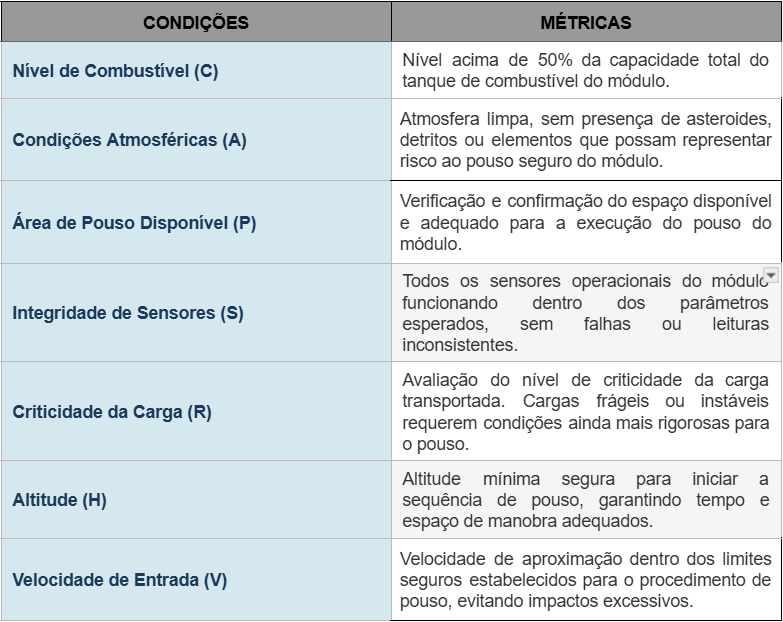

###Variáveis Críticas do Sistema
As sete variáveis críticas identificadas compõem o núcleo decisório do sistema de pouso. Cada variável é representada por uma letra mnemônica que facilita sua referência em expressões lógicas e em implementações de software ou hardware:

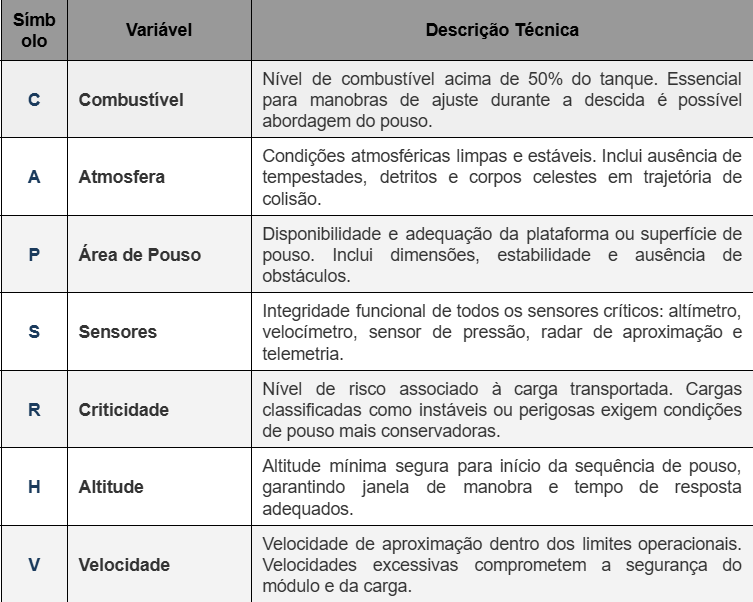

###Definição da Lógica Booleana
A autorização do pouso é definida pela conjunção lógica de todas as variáveis críticas. Em lógica booleana, a operação de conjunção é representada pelo operador AND (∧), que retorna verdadeiro somente quando TODOS os seus operandos são verdadeiros:
#####AUTORIZAR POUSO = C ∧ A ∧ P ∧ S ∧ R ∧ H ∧ V
A expressão lógica AUTORIZAR POUSO = C ∧ A ∧ P ∧ S ∧ R ∧ H ∧ V garante que o pouso somente ocorrerá quando todas as condições de segurança estiverem satisfeitas.
O bloqueio do pouso ocorre quando ao menos UMA das condições estiver insatisfeita. Pela Lei de De Morgan, a negação de uma conjunção equivale à disjunção das negações:
#####BLOQUEAR_POUSO = ¬C ∨ ¬A ∨ ¬P ∨ ¬S ∨ ¬R ∨ ¬H ∨ ¬V
A equivalência lógica entre as duas formas é garantida pela Lei de De Morgan:
#####¬(C ∧ A ∧ P ∧ S ∧ R ∧ H ∧ V)  ≡  ¬C ∨ ¬A ∨ ¬P ∨ ¬S ∨ ¬R ∨ ¬H ∨ ¬V
Isso significa que basta UMA variável assumir o valor falso (0) para que o sistema emita o bloqueio imediato. Esta é uma propriedade essencial para sistemas de segurança crítica, onde o princípio do mínimo privilégio de operação deve ser aplicado.

###Representação de portas lógicas
A lógica do sistema pode ser representada como uma porta AND de múltiplas entradas (7 entradas), onde cada entrada corresponde a uma variável crítica. A saída da porta AND é verdadeira somente quando todas as entradas são verdadeiras simultaneamente:



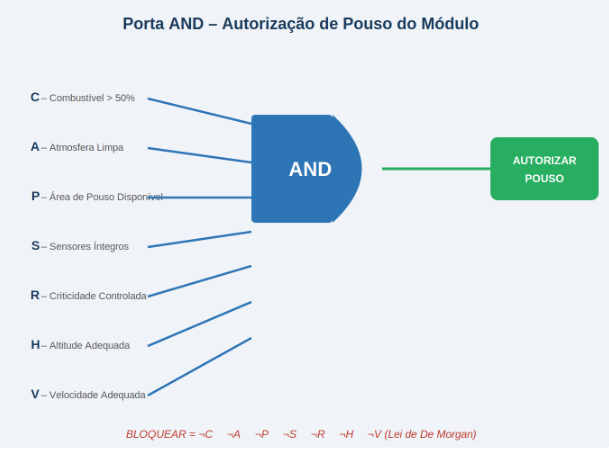


Esta representação é fundamental para a implementação em sistemas embarcados ou microcontroladores que compõem o sistema de controle de pouso do módulo espacial.


###Tabela de Decisões Binárias

A tabela verdade apresenta as combinações relevantes de valores das variáveis críticas e o resultado correspondente do sistema de decisão. Por questões de concisão, são apresentados os casos mais significativos, considerando que qualquer falha isolada resulta em bloqueio:

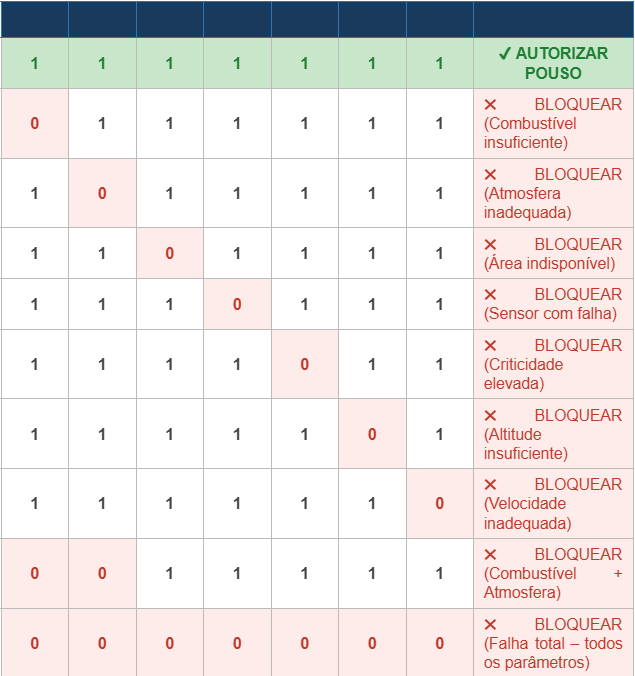

## Implementar, em Python, um protótipo do MGPEB

Dentro da classe do Gerenciador de Pouso, temos a estrutura principal que é a fila de pouso, com base nisso, podemos fazer toda a estrutura.  
Usamos a estrutura de fila em low-level dentro do módulo de Queue, e importamos no nosso código, todas as funções foram gerados para funcionar diretamente no módulo.

Usamos a estrutura de filas para armazenar a estrutura da fila de pouso, e arrays estáticos para outros usos, como manter nossa lista de alerta e nossa lista de pousados. Quanto ao uso de pilhas não se foi necessário. Você pode checar nossa estrutura da fila no nosso GitHub acessando a pasta modulos e indo em fila.py.  

Os módulos foram cadastrados na classe módulos e implementados dentro da fila de pouso com a função classificar_modulo. Lá adicionamos nas listas se for necessário, e também adicionamos na fila de pouso do MGPEB.  

Implementamos também algoritmos de busca com complexidade O(n) para conseguirmos encontrar o menor e o maior valor dos atributos "prioridade", "combustivel" e "massa". Sendo o de prioridade definido como padrão, e sendo possível passar o campo que você gostaria no parâmetro atributo.  

Com a nossa estrutura de fila, implementamos o algoritmo de merge sort para ordenarmos nossa fila. Com base nisso, adicionamos dentro da nossa classe de Fila, o algoritmo implementado onde conseguimos fazer a estrutura do Merge Sort.  

O Merge Sort funciona com o desmembramento da lista em outras listas até que ela fique uma lista unitária, e após isso, ela passa a ordenar com base em duas listas de comparação. O merge sort tem complexidade O(N log N), e com isso consegue ser mais eficiente que outros algoritmos de ordenação. Para alcançar essa complexidade, ele usa de recursão em seu ambiente até conseguir finalizar a ordenação.  

Você pode encontrar o algoritmo completo na nossa estrutura de fila.

Com as estruturas da fila e o código de ordenação, conseguimos implementar e simular a estrutura do pouso dos módulos necessários.

### Estrutura de dados utilizada no processo.

Para construção da fila de pouso, utilizamos da estrutura de Queue, fazendo toda a estrutura em baixo nível, mesmo em python, e implementando a estrutura dos Nodes, que armazenamos o valor em um ponto e adicionamos um ponteiro para um próximo Node. O último Node apontava para um Node vazio, e com isso sabíamos que ali era o último elemento da nossa lista.

O modelo de array foi utilizado usando a estrutura de listas já existentes no Python, funcionando de maneira similar.

Já a estrutura de pilhas não chegou a ser utilizada, não precisamos adicionar elementos no topo da nossa pilha. Com isso, não precisamos gerar o código da pilha.

## Modelar funções matemáticas aplicadas ao pouso ou estabilização da base

Para a Modelagem matemática, foram modelados fenômenos físicos relacionados ao pouso em Marte utilizando funções matemáticas.

A altura da nave foi representada por uma função quadrática:

$h(t)= h0 - 1/2 gt²$

onde h(t) representa a altura em função do tempo, h0  é a altura inicial, g a gravidade de Marte e t o tempo. Essa função indica que a altura diminui de forma acelerada ao longo do tempo, caracterizando uma queda livre. O gráfico dessa função é uma parábola decrescente: à medida que o tempo aumenta, a altura diminui cada vez mais rapidamente; se o tempo diminuir, a altura aumenta, aproximando-se do valor inicial.

A temperatura externa foi modelada em função do tempo a partir da relação com a altura, resultando na função:

$T(t)=T0 − k * (h0 − 1/2 gt²)$

onde T(t) representa a temperatura externa no instante de tempo t, T0 é a temperatura próxima à superfície de Marte e k é a taxa de variação da temperatura. Essa função também é quadrática, mostrando que a temperatura varia de forma não linear durante a descida. Seu gráfico é uma parábola crescente: à medida que o tempo aumenta, a temperatura tende a aumentar; se o tempo diminuir, a temperatura diminui. Além disso, essa função foi construída a partir da função da altura em relação ao tempo. Como a altura do foguete pode ser descrita por uma equação do movimento uniformemente acelerado, substitui-se essa expressão na relação de temperatura, assumindo que a temperatura depende também da altitude. Dessa forma, a temperatura passa a ser expressa em função do tempo, permitindo analisar sua variação ao longo de toda a descida de maneira contínua.

Essa modelagem auxilia nas decisões de engenharia, como o momento de abrir o paraquedas e acionar os retrofoguetes, tornando o pouso mais seguro.

## Contextualizar o MGPEB à luz da evolução da computação


A evolução dos computadores ao longo das gerações tecnológicas permitiu a transição de máquinas extremamente grandes, lentas e com alta demanda energética para sistemas embarcados compactos, robustos e altamente especializados, como os utilizados em missões espaciais. Os primeiros computadores de propósito geral marcaram o início da computação eletrônica moderna. Essas máquinas utilizavam válvulas, o que resultava em necessidade de espaço físico e alto consumo de energia, exigindo manutenção constante. Ainda assim, introduziram conceitos fundamentais como processamento automatizado, execução sequencial de instruções e armazenamento de dados.

Com a segunda geração, a substituição das válvulas por transistores trouxe maior eficiência energética, permitindo a redução de tamanho e aumento significativo de confiabilidade. Na terceira geração, os circuitos integrados permitiram miniaturização ainda maior e o surgimento de sistemas mais complexos. A quarta geração, marcada pelo desenvolvimento dos microprocessadores, consolidou a computação embarcada, tornando possível inserir capacidade computacional em veículos, equipamentos industriais, satélites e sondas espaciais. Atualmente, os sistemas embarcados de alta confiabilidade utilizados em exploração espacial representam uma evolução direta dessa trajetória histórica, combinando processamento especializado, redundância e tolerância a falhas para operar em ambientes extremos.

Em uma missão para Marte, as limitações de hardware são significativamente mais severas do que em sistemas computacionais terrestres convencionais. Diferentemente de um servidor moderno ou de um computador pessoal, um sistema embarcado marciano precisa operar sob influência de variáveis físicas do ambiente de Marte, com memória restrita, baixa capacidade de processamento,  limitação energética e alta resistência à radiação cósmica.

A radiação representa um dos maiores desafios computacionais em missões espaciais. Partículas energéticas podem causar fenômenos como bit flips, em que um bit armazenado muda de valor espontaneamente, comprometendo cálculos e decisões críticas. Por isso, utiliza-se hardware rad-hard (radiation-hardened), projetado especificamente para resistir a essas interferências. Entretanto, esse tipo de hardware costuma apresentar menor desempenho e maior custo de fabricação. Além disso, como a energia disponível depende fortemente de painéis solares ou baterias de longa duração, o consumo energético precisa ser rigidamente controlado, sendo necessário algoritmos mais eficientes.

Essas restrições influenciam diretamente as escolhas de algoritmos e estruturas de dados do sistema projetado. Em vez de soluções sofisticadas com alta complexidade computacional, priorizam-se algoritmos determinísticos, simples, previsíveis e com baixo custo de execução.

Portanto, a história da computação mostra que os avanços iniciados com os primeiros computadores de propósito geral não apenas transformaram a sociedade, mas também viabilizaram aplicações extremamente sofisticadas como os sistemas embarcados interplanetários. Em um ambiente hostil como Marte, a eficiência não está associada ao maior poder computacional, mas sim à confiabilidade, previsibilidade e resiliência. Isso exige que o projeto de software e hardware seja orientado menos pela performance máxima e mais pela garantia de funcionamento contínuo em condições extremas.

## Incorporar princípios ESG à concepção da base Aurora

A implantação de uma colônia em Marte exige que a operação seja pensada não apenas sob a ótica tecnológica e de sobrevivência, mas também sob uma perspectiva de governança ambiental, social e corporativa (ESG — Environmental, Social and Governance). Em um ambiente extremo, isolado e de recursos limitados, decisões mal planejadas podem comprometer não apenas a continuidade da missão, mas também a preservação científica e ética da exploração espacial. Dessa forma, a sustentabilidade da colônia precisa ser tratada como um princípio estrutural e não apenas como uma meta secundária.

No aspecto ambiental, a escolha da área de pouso deve seguir critérios rigorosos que minimizem impactos sobre o ecossistema marciano. A chamada proteção planetária (planetary protection) estabelece que a exploração espacial deve evitar tanto a contaminação de Marte por organismos terrestres quanto a possível contaminação reversa da Terra. Assim, regiões com alto valor científico — como áreas com presença de gelo subterrâneo, antigos leitos de rios, cavernas ou locais com maior potencial de evidência biológica — devem ser cuidadosamente avaliadas e, em muitos casos, preservadas de ocupação permanente.

A gestão de energia representa outro pilar essencial da sustentabilidade marciana. Como a disponibilidade energética será limitada e altamente estratégica, a colônia deverá operar com um sistema híbrido baseado principalmente em energia solar, complementado por reatores nucleares compactos de alta confiabilidade. A distribuição de energia precisa priorizar atividades críticas, enquanto atividades secundárias devem operar sob políticas rígidas. O consumo energético, em longas missões, é uma questão de sobrevivência coletiva.

Da mesma forma, a gestão de resíduos precisa abandonar completamente a lógica linear de consumo terrestre baseada em descarte. Em Marte, praticamente tudo deve operar dentro de um modelo circular, é preciso reutilizar e reciclar todos os recursos disponíveis. O uso de recursos locais reduz dependência logística da Terra e aumenta a autonomia da colônia, mas exige governança rigorosa para evitar exploração predatória ou irreversível do ambiente marciano.

Uma possibilidade seria a criação de conselhos multidisciplinares com participação técnica, científica e representativa da própria comunidade local, funcionando de forma semelhante a comitês de governança corporativa e bioética. Esses conselhos poderiam supervisionar decisões críticas, estabelecer limites operacionais e garantir que interesses econômicos ou políticos não se sobreponham à segurança humana e à preservação científica. Além disso, registros transparentes das decisões e auditorias periódicas seriam fundamentais, inclusive com supervisão internacional, já que Marte não pertence juridicamente a nenhuma nação específica segundo o Outer Space Treaty.

Portanto, a governança de uma colônia em Marte precisa unir eficiência técnica e responsabilidade ética. Sustentabilidade marciana não significa apenas economizar recursos, mas preservar o equilíbrio entre exploração, preservação científica, dignidade humana e legitimidade institucional. O verdadeiro sucesso de uma colônia interplanetária não será medido apenas pela capacidade de sobreviver em Marte, mas pela capacidade de construir ali uma sociedade tecnologicamente avançada e moralmente responsável.